In [1]:
import igraph as ig
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

rng = np.random.default_rng()

In [2]:
def find(ptr, i):
    while ptr[i] != -1:
        i = ptr[i]
    return i


def newman_ziff(neighbours, order, no_bar=False):
    n = len(neighbours)
    parent = np.full(n, -1, dtype="int32")
    size = np.zeros(n, dtype="uint32")
    lcc, clus = np.zeros(n, dtype="uint32"), np.zeros(n, dtype="uint32")
    n_clusters, lcc_size = 0, 0
    for idx in tqdm(range(n), disable=no_bar):
        root = order[idx]
        size[root] = 1
        n_clusters += 1
        for near in neighbours[root]:
            if size[near]:
                near = find(parent, near)
                if near != root:
                    n_clusters -= 1
                    if size[root] < size[near]:
                        size[near] += size[root]
                        parent[root] = near
                        root = near
                    else:
                        size[root] += size[near]
                        parent[near] = root
        if lcc_size < size[root]:
            lcc_size = size[root]
        lcc[idx] = lcc_size
        clus[idx] = n_clusters
    return lcc, clus

In [3]:
g = ig.Graph.Lattice([100, 100], circular=False)
adj_list = g.get_adjlist()
n_nodes = g.vcount()

In [20]:
n_repeat = 1000

lcc = np.zeros((n_repeat, n_nodes), dtype="uint64")
clus = np.zeros((n_repeat, n_nodes), dtype="uint64")
for idx in tqdm(range(n_repeat)):
    order = rng.permutation(n_nodes)
    lcc[idx], clus[idx] = newman_ziff(adj_list, order, no_bar=True)

  0%|          | 0/1000 [00:00<?, ?it/s]

(0.4, 0.8)

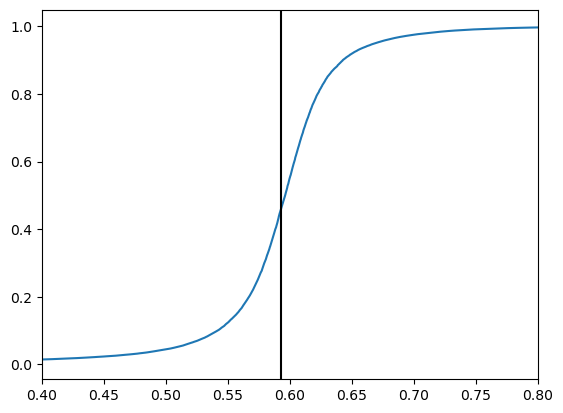

In [36]:
prob = np.arange(1, n_nodes + 1) / n_nodes
strength = np.mean(lcc, axis=0) / n_nodes
p_inf = np.mean(lcc, axis=0) / np.arange(1, n_nodes + 1)
av_size = (np.arange(1, n_nodes + 1) - np.mean(lcc, axis=0)) / np.mean(clus, axis=0)
# plt.plot(prob, strength)
plt.plot(prob, p_inf)
# plt.plot(prob, av_size)
plt.axvline(0.5927, c="k")
plt.xlim(0.4, 0.8)

# P span

In [133]:
def perc_spanning(neighbours, order, no_bar=False):
    n = len(neighbours)
    parent = np.full(n, -1, dtype="int32")
    size = np.zeros(n, dtype="uint32")
    spanning = np.zeros(n, dtype="bool")
    for idx in tqdm(range(n), disable=no_bar):
        root = order[idx]
        size[root] = 1
        for near in neighbours[root]:
            if size[near]:
                near = find(parent, near)
                if near != root:
                    if size[root] < size[near]:
                        size[near] += size[root]
                        parent[root] = near
                        root = near
                    else:
                        size[root] += size[near]
                        parent[near] = root
        spanning[idx] = find(parent, 0) == find(parent, n - 1)
    return spanning

In [134]:
l = 100
g = ig.Graph.Lattice([l + 2, l], circular=False)
adj_list = g.get_adjlist()
n_nodes = g.vcount()
borders = list(range(0, n_nodes, l + 2)) + list(range(l + 1, n_nodes, l + 2))
grid = [x for x in range(n_nodes) if x not in borders]

In [140]:
n_repeat = 1000

p_span = np.zeros(n_nodes, dtype="float64")
for idx in tqdm(range(n_repeat)):
    order = rng.permutation(grid)
    order = np.concatenate((borders, order))
    p_span += perc_spanning(adj_list, order, no_bar=True)
p_span /= n_repeat

  0%|          | 0/1000 [00:00<?, ?it/s]

(0.4, 0.8)

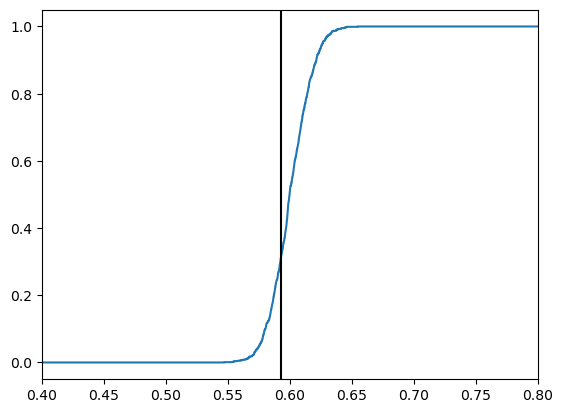

In [145]:
prob = np.arange(1, n_nodes + 1) / n_nodes
plt.plot(prob, p_span)
plt.axvline(0.5927, c="k")
plt.xlim(0.4, 0.8)

# P span test

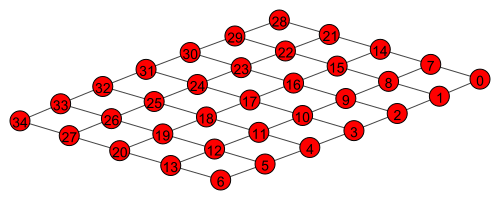

In [122]:
l = 5
g = ig.Graph.Lattice([l + 2, l], circular=False)
adj_list = g.get_adjlist()
n_nodes = g.vcount()
ig.plot(g, layout="kamada_kawai", bbox=(500, 200), vertex_label=g.vs.indices)

In [123]:
borders = list(range(0, n_nodes, l + 2)) + list(range(l + 1, n_nodes, l + 2))
grid = [x for x in range(n_nodes) if x not in borders]
order = rng.permutation(grid)
order = np.concatenate((borders, order))
order

array([ 0,  7, 14, 21, 28,  6, 13, 20, 27, 34,  2, 26, 12, 16, 19, 32, 10,
       15, 17, 24, 25, 33,  4,  8,  5, 11, 23,  3,  1,  9, 22, 29, 31, 30,
       18])

In [124]:
from ipywidgets import IntSlider, interact, fixed

def plotter(frame, order, graph):
    colored = order[:frame+1]
    nodes = range(graph.vcount())
    colors = ["cyan" if id in colored else "red" for id in nodes]
    fig, ax = plt.subplots(figsize=(10, 5))
    ig.plot(
        graph,
        target=ax,
        layout="kk",
        vertex_size=0.5,
        vertex_color=colors,
        vertex_label=nodes,
        vertex_label_size=10,
    )

In [125]:
interact(
    plotter,
    frame=IntSlider(0, 0, len(order) - 1),
    order=fixed(order),
    graph=fixed(g)
)

interactive(children=(IntSlider(value=0, description='frame', max=34), Output()), _dom_classes=('widget-intera…

<function __main__.plotter(frame, order, graph)>

In [132]:
np.nonzero(perc_spanning(g.get_adjlist(), order))

  0%|          | 0/35 [00:00<?, ?it/s]

(array([20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34],
       dtype=int64),)

# plotter

In [55]:
from ipywidgets import IntSlider, interact, fixed


def plotter(frame, order, graph):
    colored = order[:frame+1]
    nodes = range(graph.vcount())
    colors = ["cyan" if id in colored else "red" for id in nodes]
    fig, ax = plt.subplots(figsize=(10, 5))
    ig.plot(
        graph,
        target=ax,
        layout="grid",
        vertex_size=0.5,
        vertex_color=colors,
        vertex_label=nodes,
        vertex_label_size=10,
    )

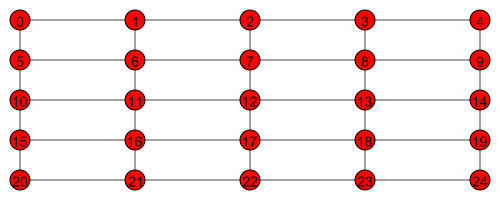

In [56]:
grid = ig.Graph.Lattice([5, 5], circular=False)
ig.plot(grid, layout="grid", bbox=(500, 200), vertex_label=grid.vs.indices)

In [57]:
order = rng.permutation(grid.vcount())
order

array([20, 18, 22,  6, 14, 23,  0, 16,  2, 17, 19, 11,  5, 12,  7,  4, 21,
       15,  1, 10, 24, 13,  9,  8,  3])

In [58]:
interact(
    plotter,
    frame=IntSlider(0, 0, len(order) - 1),
    order=fixed(order),
    graph=fixed(grid)
)

interactive(children=(IntSlider(value=0, description='frame', max=24), Output()), _dom_classes=('widget-intera…

<function __main__.plotter(frame, order, graph)>